## Image analysis using Fourier transforms (Open in Colab)
On this notebook, we'll not focus on the frequencies or the correct axis interpolation to plot them. The main objective is to see how some common objects transform in Fourier space.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

## 1. Fourier transform of a disc

https://www.geeksforgeeks.org/python-pil-imagedraw-draw-ellipse/

In [2]:
im1 = Image.new(mode="RGB", size=(300, 300))

draw = ImageDraw.Draw(im1)

draw.ellipse((100, 50, 200, 250), fill=(255, 0, 0), outline=(0, 0, 0))

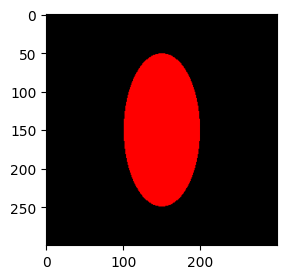

In [3]:
#Plotting the disc

plt.figure(figsize=(4,3))

plt.imshow(im1)

plt.show()

In [4]:
print(np.array(im1).shape)

print(np.array(im1)[:,:,0].shape)

# Select the R channel (0: Red, 1: Green, 2: Blue)

im1_red = np.array(im1)[:,:,0]

print(np.max(im1_red), np.min(im1_red))

(300, 300, 3)
(300, 300)
255 0


In [5]:
type(im1)

# Binary image
image_1 = im1_red//255

print(image_1.shape)

print(np.unique(image_1))

(300, 300)
[0 1]


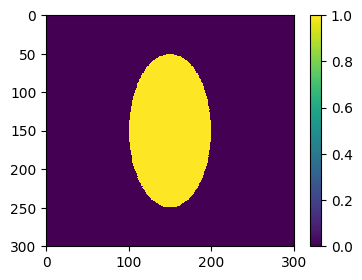

In [6]:
#Plotting the binary map

plt.figure(figsize = (4,3))

Z1 = plt.pcolor(image_1, shading='auto', cmap = "viridis", vmin = 0, vmax=1)
plt.gca().invert_yaxis()
plt.colorbar(Z1)

plt.show()

## Fourier transform of the disc

In [7]:
#2D FFT
fourier_1 = np.fft.fft2(image_1)

#Shift frequencies to the center
shifted_fourier_1 = np.fft.fftshift(fourier_1)

#Get the real values
norm_fourier_1 = np.abs(shifted_fourier_1)

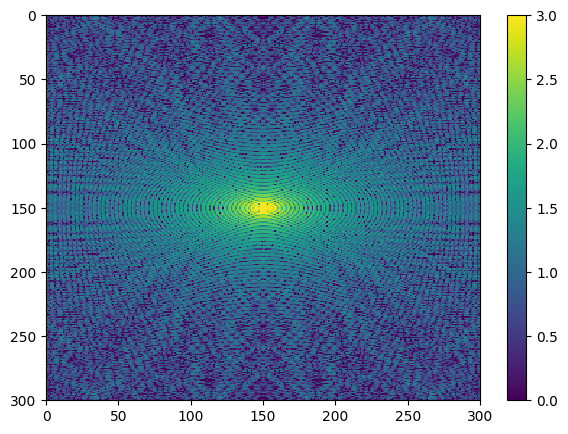

In [8]:
#Plotting the Fourier transform of the ellipse

plt.figure(figsize = (7,5))

Z1 = plt.pcolor(np.log10(norm_fourier_1), shading='auto', cmap = "viridis", vmin = 0, vmax=3)
plt.gca().invert_yaxis()
plt.colorbar(Z1)

plt.show()

## 2. Fourier transform of a block

https://www.geeksforgeeks.org/python-pil-imagedraw-draw-line/

In [9]:
#Import the block

im2 = Image.new(mode="RGB",size=(300, 300))

draw = ImageDraw.Draw(im2)

draw.line((200, 200, 100, 100), fill=(255, 255, 0), width=10)

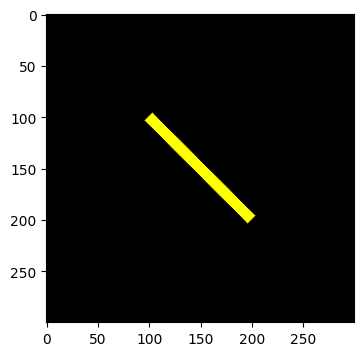

In [10]:
#Plotting

plt.figure(figsize=(7,4))

plt.imshow(im2)

plt.show()

In [11]:
#Select the R layer and normalize to a binary

image_2 = np.array(im2)[:,:,0]//255

print(np.max(image_2))

print(np.min(image_2))

1
0


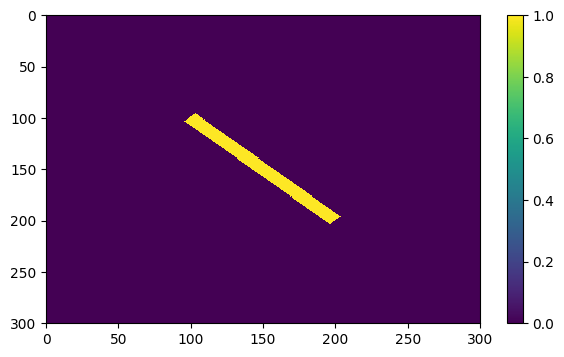

In [12]:
#Plotting R layer

plt.figure(figsize = (7,4))

Z1 = plt.pcolor(image_2, shading='auto', cmap = "viridis", vmin = 0, vmax=1)
plt.gca().invert_yaxis()
plt.colorbar(Z1)

plt.show()

In [13]:
#2D FFT
fourier_2 = np.fft.fft2(image_2)

#Shift frequencies to the center
shifted_fourier_2 = np.fft.fftshift(fourier_2)

#Get the real values
norm_fourier_2 = np.abs(shifted_fourier_2)

<ipython-input-14-6be670eea2c4>:5: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(norm_fourier_2), shading='auto', cmap = "viridis", vmin = 0, vmax=3)


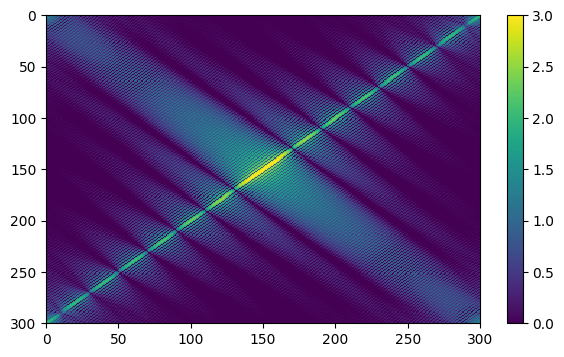

In [14]:
#Plotting the Fourier transform of the block

plt.figure(figsize = (7,4))

Z1 = plt.pcolor(np.log10(norm_fourier_2), shading='auto', cmap = "viridis", vmin = 0, vmax=3)
plt.gca().invert_yaxis()
plt.colorbar(Z1)

plt.show()

High frequencies match the edges.

## 3. Fourier transform of a Rubik's cube

https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/Rubiks_cube.jpg

In [15]:
from google.colab import drive
import matplotlib.image as mpimg

In [16]:
# Read image:

drive.mount('/content/drive')

img = mpimg.imread("/content/drive/MyDrive/Colab Notebooks/data/Rubiks_cube.jpg")

print(img.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1600, 1600, 3)


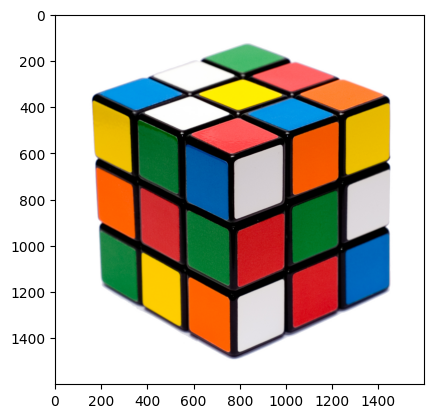

In [17]:
# See the image

plt.figure()

plt.imshow(img)

plt.show()

In [18]:
# Select R layer, 2D image:

image_3 = img[:,:,0]
print(image_3.shape)

(1600, 1600)


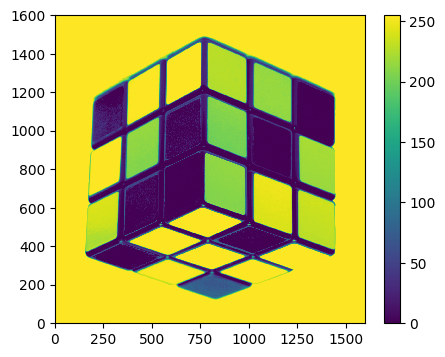

In [19]:
#Plotting R layer

plt.figure(figsize = (5,4))

Z1 = plt.pcolor(image_3, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()

### Fourier transform:

In [20]:
#2D FFT
fourier_3 = np.fft.fft2(image_3)

#Shift frequencies to the center
shifted_fourier_3 = np.fft.fftshift(fourier_3)

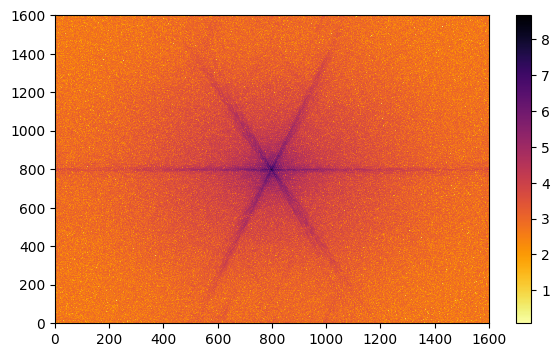

In [21]:
#Plotting the Fourier transform of the Rubik's cube

plt.figure(figsize = (7,4))

Z1 = plt.pcolor(np.log10(np.abs(shifted_fourier_3)), shading='auto', cmap ="inferno_r")

plt.colorbar(Z1)

plt.show()

### Low-pass filter:

We need to construct a mask to just get the frequencies at the center, the low frequencies. (The bar of the plot above DOES NOT represent the frequency values)

In [22]:
#Define the centre of the image
image_centre = [shifted_fourier_3.shape[0]//2, shifted_fourier_3.shape[1]//2]

print(image_centre)

radius_centre = 50 #pixels

[800, 800]


In [23]:
#Draw a circle in the center. The position is given by the FT
mask_1 = Image.new(mode="RGB", size=(1600, 1600))

draw = ImageDraw.Draw(mask_1)

draw.ellipse((image_centre[0]-radius_centre, image_centre[1]-radius_centre, image_centre[0]+radius_centre, image_centre[1]+radius_centre), fill=(255, 0, 0), outline=(0, 0, 0))

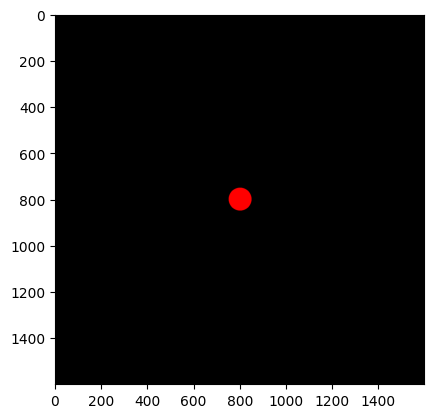

255 0


In [24]:
#Plotting mask

plt.figure()

plt.imshow(mask_1)

plt.show()

print(np.max(mask_1), np.min(mask_1))

In [25]:
#Select R layer and convert to a binary
mask_1 = np.array(mask_1)[:,:,0]//255

print(np.unique(mask_1))

[0 1]


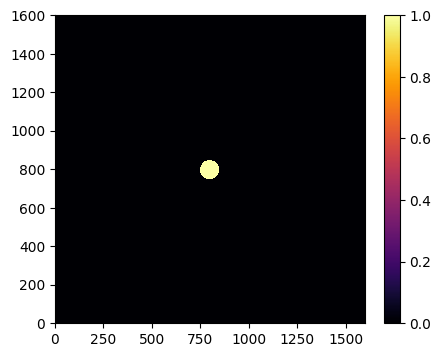

In [26]:
#Plotting binary mask
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(mask_1, shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Multiply the mask by the Fourier image

In [27]:
masked_fourier_3 = shifted_fourier_3*mask_1

### Plotting low-pass filter masking of FT of the Rubik's cube:

<ipython-input-28-5bf082dac6f7>:3: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(masked_fourier_3)), shading='auto', cmap ="inferno") #recall to just get the real values


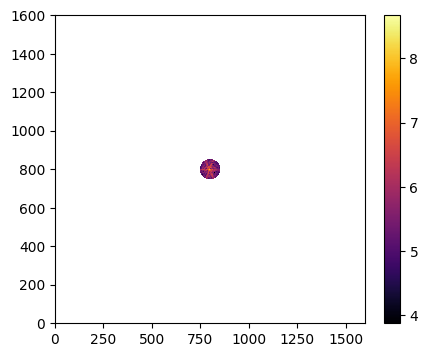

In [28]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(np.log10(np.abs(masked_fourier_3)), shading='auto', cmap ="inferno") #recall to just get the real values

plt.colorbar(Z1)

plt.show()

### Inverse Fourier transform of the masked Fourier image

In [29]:
#First, shift back the frequencies
inv_filter_3 = np.fft.ifftshift(masked_fourier_3)

#Then, carry out the IFFT
inv_filter_3 = np.fft.ifft2(inv_filter_3)

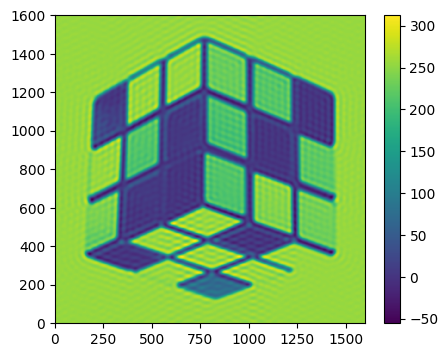

In [30]:
#Plotting the masked Rubik's cube

plt.figure(figsize = (5,4))

Z1 = plt.pcolor(inv_filter_3.real, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()

The edges (details) have been smoothed out.

### High pass filter:

Removes low frequency (large scale) structures.

For the mask, we now want everything outside the center, the high frequencies.

In [31]:
mask_2 = - mask_1 + 1 #the +1 is to convert the image to a binary

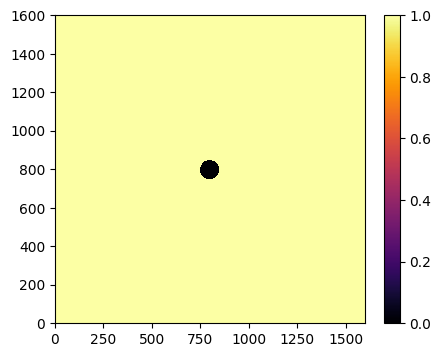

In [32]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(mask_2, shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Multiply mask 2 by the fourier image:

In [33]:
masked_fourier_3_2 = shifted_fourier_3*mask_2

### Plotting high-pass filter masking of FT of the Rubik's cube:

<ipython-input-34-5bd5e1c035cc>:3: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(masked_fourier_3_2)), shading='auto', cmap ="inferno")


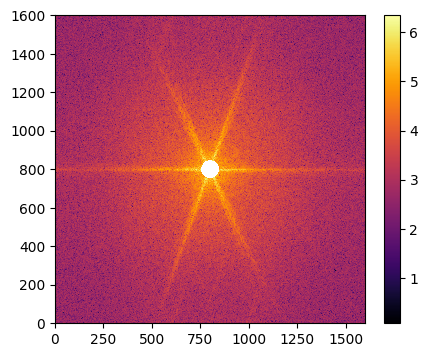

In [34]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(np.log10(np.abs(masked_fourier_3_2)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Inverse Fourier transform of the masked Fourier image

In [35]:
#First, shift back the frequencies
inv_filter_3_2 = np.fft.ifftshift(masked_fourier_3_2)

#Then, carry out the IFFT
inv_filter_3_2 = np.fft.ifft2(inv_filter_3_2)

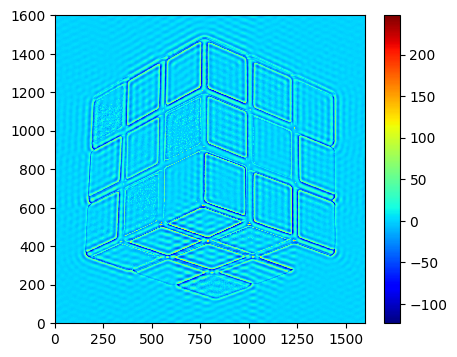

In [36]:
#Plotting the masked Rubik's cube

plt.figure(figsize = (5,4))

Z1 = plt.pcolor(inv_filter_3_2.real, shading='auto', cmap ="jet")

plt.colorbar(Z1)

plt.show()

We have isolated the details and removed the large scale structure. It's kind of like an edge detector.

## 4. Fourier transform of 2D noise:

https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html

In [37]:
noise_array = np.random.randn(300, 300)

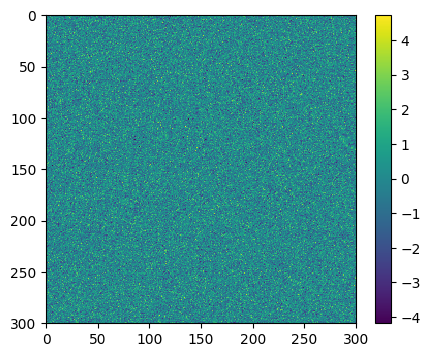

In [38]:
plt.figure(figsize = (5,4))
plt.gca().invert_yaxis()
Z1 = plt.pcolor(noise_array, shading='auto', cmap = "viridis")#, vmin = 0, vmax=3)

plt.colorbar(Z1)

plt.show()

### Fourier transform of the 2D noise:

In [39]:
fourier_4 = np.fft.fft2(noise_array)

shifted_fourier_4 = np.fft.fftshift(fourier_4)

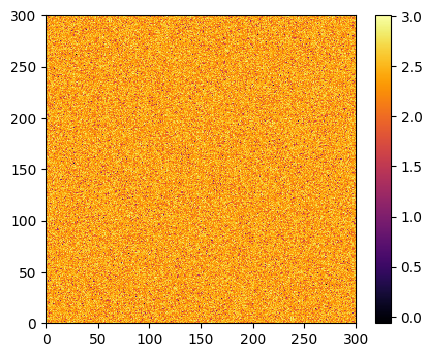

In [40]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(np.log10(np.abs(fourier_4)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

Noise populates everything. To remove it we must use $\textbf{amplitude}$ thresholding or smoothing.

In [41]:
kx = np.linspace(0, 300, 300)
ky = np.linspace(0, 300, 300)

kx_2d, ky_2d = np.meshgrid(kx, ky)

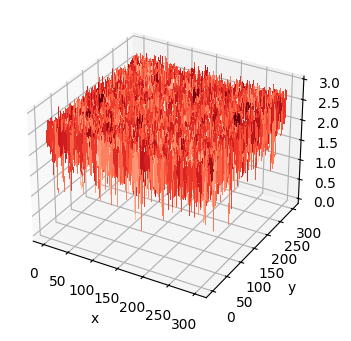

In [42]:
# Now we do some plotting:
fig = plt.figure(figsize = (5,4))

ax = plt.axes(projection='3d')
#ax.contour3D(X, Y, norm_fourier_Z_f, 100, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface
surf = ax.plot_surface(kx_2d, ky_2d, np.log10(np.abs(fourier_4)), cmap = "Reds", linewidth=0, antialiased=False)

ax.set_xlabel('x')  # Customised labels for axes
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()